##Imports

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

##Load Dataset

In [4]:
df = pd.read_csv("data/Loan_Default.csv")

df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


##Basic Info

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


##Target Distribution

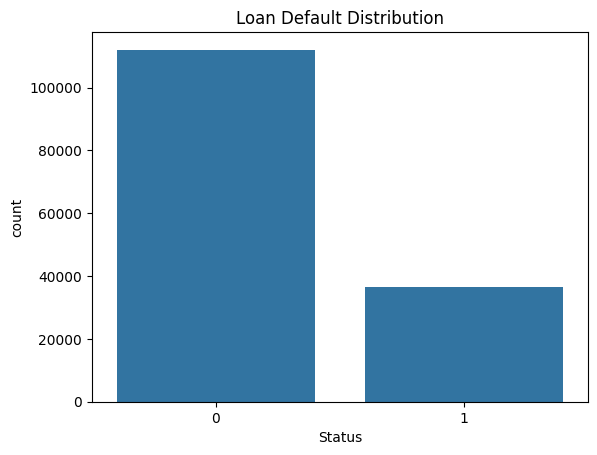

In [6]:
df["Status"].value_counts(normalize=True)

sns.countplot(x="Status", data=df)
plt.title("Loan Default Distribution")
plt.show()

##Drop Irrelevant / Leakage Columns

In [7]:
df.drop("ID", axis=1, inplace=True)

leak_cols = [
    "Interest_rate_spread",
    "Upfront_charges",
    "rate_of_interest",
    "dtir1",
    "credit_type"
]

df.drop(columns=leak_cols, errors="ignore", inplace=True)
df.drop("year", axis=1, inplace=True)

##Handle Missing Values

In [8]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

##Outlier Treatment (Winsorization)

In [9]:
for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

##Correlation Analysis

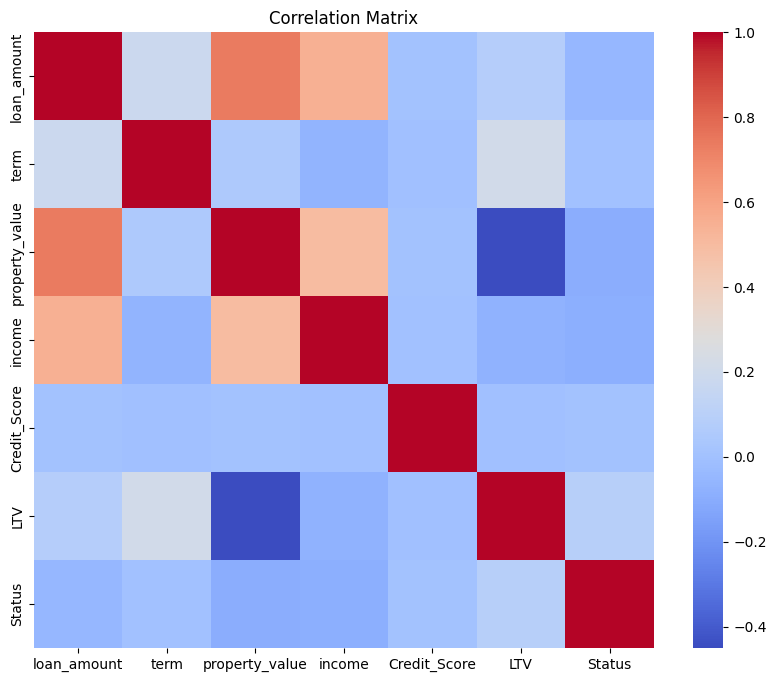

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

##Feature Engineering

In [11]:
df["loan_income_ratio"] = df["loan_amount"] / (df["income"] + 1)
df["loan_property_ratio"] = df["loan_amount"] / (df["property_value"] + 1)
df["credit_income_ratio"] = df["Credit_Score"] / (df["income"] + 1)
df["loan_credit_ratio"] = df["loan_amount"] / (df["Credit_Score"] + 1)
df["property_income_ratio"] = df["property_value"] / (df["income"] + 1)

##Handle Infinite Values

In [12]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

##Encoding

In [13]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

##Train-Test Split

In [14]:
X = df.drop("Status", axis=1)
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##Scaling

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Model Training (Random Forest)

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

##Evaluation

In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", roc_auc)

[[22139   267]
 [ 3137  4191]]
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     22406
           1       0.94      0.57      0.71      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.78      0.82     29734
weighted avg       0.89      0.89      0.88     29734

ROC AUC Score: 0.8700977204815303


##ROC Curve

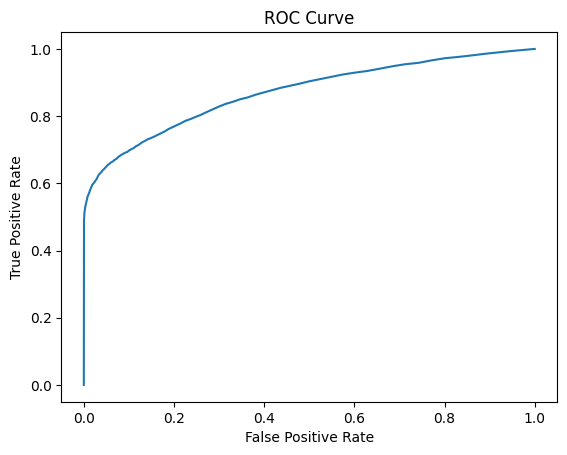

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

##Feature Importance

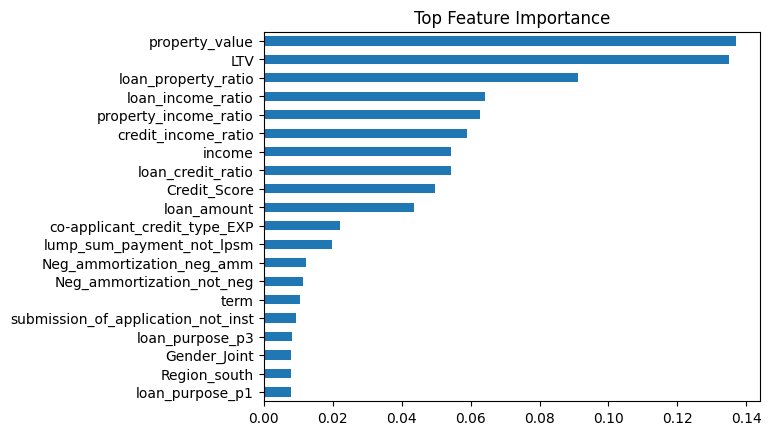

In [19]:
importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)
feature_importance.sort_values(ascending=True).tail(20).plot(kind="barh")

plt.title("Top Feature Importance")
plt.show()

##Business Cost Evaluation

In [20]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

cost_fp = 10000
cost_fn = 100000

total_cost = (fp * cost_fp) + (fn * cost_fn)

print("False Positives:", fp)
print("False Negatives:", fn)
print("Estimated Business Loss:", total_cost)

False Positives: 267
False Negatives: 3137
Estimated Business Loss: 316370000


##Threshold Tuning

In [21]:
threshold = 0.6

y_pred_custom = (y_prob > threshold).astype(int)

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[22319    87]
 [ 3412  3916]]
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     22406
           1       0.98      0.53      0.69      7328

    accuracy                           0.88     29734
   macro avg       0.92      0.77      0.81     29734
weighted avg       0.89      0.88      0.87     29734

